# 08 — Figure 3 replica

Reproduces Oliver et al. (2018) **Fig. 3**, "Identification of excess trends in
marine heatwave properties globally": linear trends in

| | | | |
|---|---|---|---|
| **a** MHW frequency | **b** MHW intensity | **c** MHW duration | (left column) |
| **d** mean SST | **e** SST variance | **f** SST skewness | (right column) |

Trends are **Theil–Sen**, matching the paper's stated estimator and this
replication's headline statistic.

## Colour scale

The paper uses a diverging blue–white–red scale with **non-uniform** level
boundaries — panel c, for instance, breaks at ±2.5, 5, 10 and 50 days/decade.
That is a `BoundaryNorm`, not a linear scale, and it is what makes the maps
readable: a linear scale would be swamped by a handful of extreme cells. The
boundaries below are read off the colourbars of the published figure.

Blue–white–red is colour-vision safe by construction (it opposes blue and red
rather than red and green), which `pixi run check-colors` confirms for the
Fig. 2 palette.

## Hatching

In the paper, **d–f** are hatched where the trend differs significantly from
zero (p < 0.05) — reproduced here from the Theil–Sen confidence interval.

**a–c are NOT hatched here.** In the paper their hatching marks trends
significantly different from *what mean-SST warming alone would produce*,
derived from a stochastic AR(1) climate model requiring a Monte Carlo ensemble
of full MHW detections — roughly 6.7 core-hours per realisation. That test was
deliberately not run; the panels show the trends without the excess-trend
significance. See `docs/verification-checks.md`.

In [1]:
import os
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from matplotlib.colors import BoundaryNorm
from scipy import stats

TARGET_RES_DEG = float(os.environ.get("MHW_TARGET_RES_DEG", 1.0))
RESULTS_DIR = Path("../results")
FIG_DIR = Path("../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
mhw = xr.open_dataset(RESULTS_DIR / f"mhw_annual_{TARGET_RES_DEG:g}deg.nc")
sst = xr.open_dataset(RESULTS_DIR / f"sst_annual_stats_{TARGET_RES_DEG:g}deg.nc")
years = mhw["year"].values.astype(float)
print(f"MHW  {dict(mhw.sizes)}")
print(f"SST  {dict(sst.sizes)}")

MHW  {'year': 35, 'longitude': 336, 'latitude': 145}
SST  {'year': 35, 'latitude': 180, 'longitude': 336}


## Per-cell Theil–Sen trends

In [3]:
def trend_per_decade(da: xr.DataArray, yrs: np.ndarray):
    """Theil-Sen slope per decade, and whether its 95% CI excludes zero."""
    vals = da.transpose("year", "latitude", "longitude").values
    ny, nlat, nlon = vals.shape
    flat = vals.reshape(ny, -1)
    slope = np.full(flat.shape[1], np.nan)
    signif = np.zeros(flat.shape[1], dtype=bool)
    for i in range(flat.shape[1]):
        y = flat[:, i]
        ok = np.isfinite(y)
        # Theil-Sen on a handful of points is meaningless; require most of the
        # record. Cells failing this stay NaN rather than contributing noise.
        if ok.sum() < 20:
            continue
        s, _, lo, hi = stats.theilslopes(y[ok], yrs[ok], alpha=0.95)
        slope[i] = s * 10.0
        signif[i] = (lo > 0) or (hi < 0)
    return slope.reshape(nlat, nlon), signif.reshape(nlat, nlon)


# Panel definitions: (label, title, data, colourbar levels, unit)
PANELS = [
    ("a", "MHW frequency linear trend", mhw["mhw_events"],
     [-3.5, -2.0, -1.0, -0.5, 0.5, 1.0, 2.0, 3.5], "Count per decade", False),
    ("b", "MHW intensity linear trend", mhw["mhw_intensity"],
     [-0.75, -0.50, -0.25, -0.10, 0.10, 0.25, 0.50, 0.75], "°C per decade", False),
    ("c", "MHW duration linear trend", mhw["mhw_duration"],
     [-50, -10, -5, -2.5, 2.5, 5, 10, 50], "Days per decade", False),
    ("d", "Mean SST linear trend", sst["sst_mean"],
     [-0.9, -0.6, -0.3, -0.1, 0.1, 0.3, 0.6, 0.9], "°C per decade", True),
    ("e", "SST variance linear trend", sst["sst_variance"],
     [-1.50, -0.50, -0.15, -0.05, 0.05, 0.15, 0.50, 1.50], "°C² per decade", True),
    ("f", "SST skewness linear trend", sst["sst_skewness"],
     [-1.00, -0.74, -0.50, -0.10, 0.10, 0.50, 0.74, 1.00], "Per decade", True),
]

computed = []
for key, title, da, levels, unit, hatch in PANELS:
    sl, sig = trend_per_decade(da, years)
    # Each panel carries its own grid: the MHW file holds only the 145 ocean
    # latitude rows that survived detection, the SST-statistics file all 180.
    computed.append((key, title, sl, sig, levels, unit, hatch,
                     da["longitude"].values, da["latitude"].values))
    print(f"  {key}: median {np.nanmedian(sl):+8.4f}, "
          f"{100 * np.nanmean(sig[np.isfinite(sl)]):5.1f}% significant", flush=True)

  a: median  +0.0000,   7.5% significant


  b: median  +0.0012,   8.0% significant


  c: median  +1.4493,  18.0% significant


  d: median  +0.1227,  54.4% significant


  e: median  -0.0006,  15.9% significant


  f: median  +0.0005,   9.3% significant


## The figure

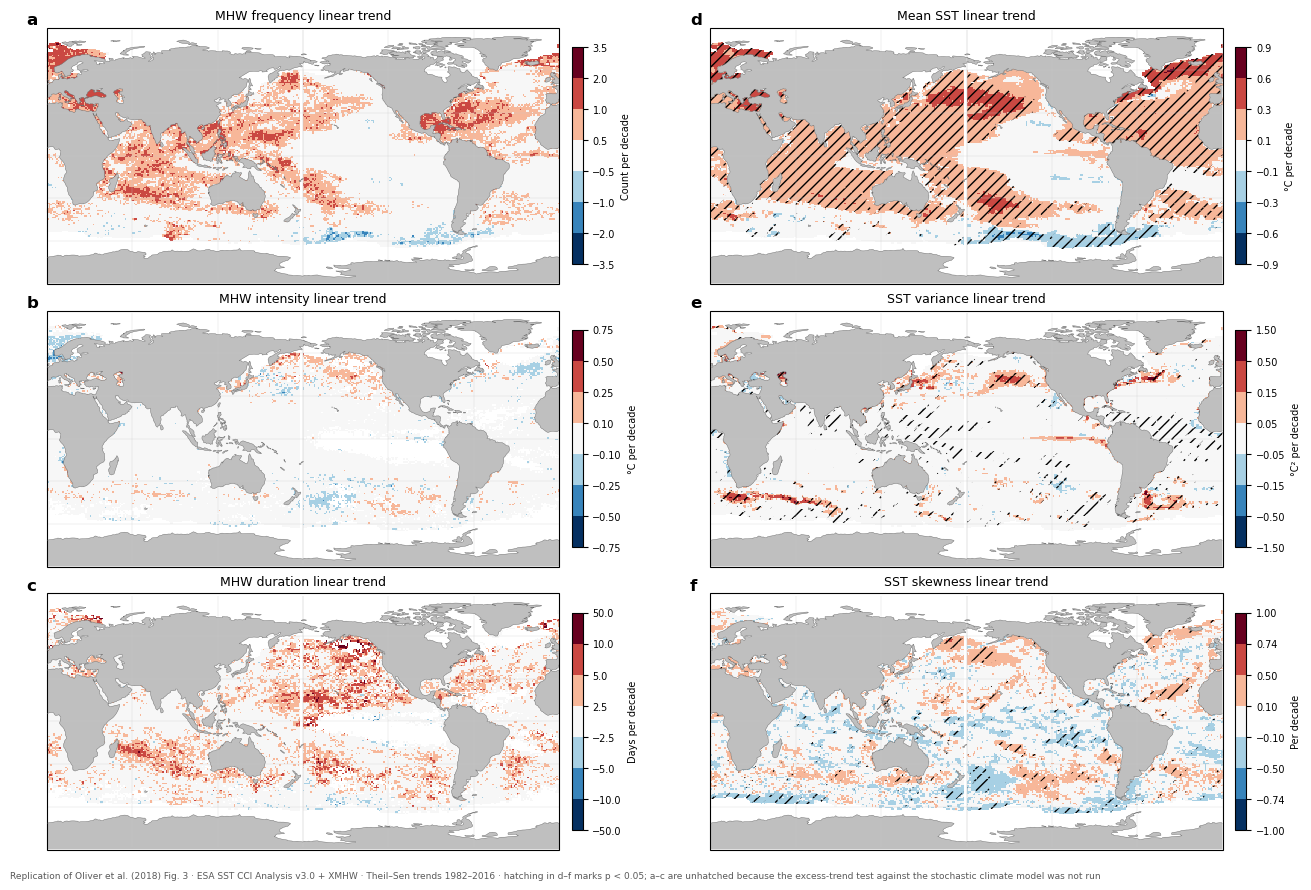

In [4]:
proj = ccrs.PlateCarree(central_longitude=180)

fig = plt.figure(figsize=(13.5, 9))
# Paper layout: a,b,c down the left column; d,e,f down the right.
order = [0, 3, 1, 4, 2, 5]

for slot, idx in enumerate(order):
    key, title, sl, sig, levels, unit, hatch, lon, lat = computed[idx]
    ax = fig.add_subplot(3, 2, slot + 1, projection=proj)

    cmap = plt.get_cmap("RdBu_r", len(levels) - 1)
    norm = BoundaryNorm(levels, cmap.N)
    mesh = ax.pcolormesh(lon, lat, sl, cmap=cmap, norm=norm,
                         transform=ccrs.PlateCarree(), shading="auto")

    if hatch:
        # Hatch where the trend is significantly different from zero.
        ax.contourf(lon, lat, sig.astype(float), levels=[0.5, 1.5],
                    colors="none", hatches=["///"],
                    transform=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="0.75", zorder=2)
    ax.coastlines(linewidth=0.3, color="0.4", zorder=3)
    ax.set_global()
    gl = ax.gridlines(draw_labels=False, linewidth=0.2, color="0.8")
    ax.set_title(title, fontsize=9)
    ax.text(-0.04, 1.06, key, transform=ax.transAxes,
            fontsize=12, fontweight="bold", va="top")

    cb = fig.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02,
                      shrink=0.85, ticks=levels)
    cb.ax.tick_params(labelsize=7)
    cb.set_label(unit, fontsize=7)

fig.suptitle("", y=0.995)
fig.text(0.01, 0.005,
         "Replication of Oliver et al. (2018) Fig. 3 · ESA SST CCI Analysis v3.0 "
         "+ XMHW · Theil–Sen trends 1982–2016 · hatching in d–f marks p < 0.05; "
         "a–c are unhatched because the excess-trend test against the stochastic "
         "climate model was not run",
         fontsize=6.5, color="0.35")

fig.tight_layout(rect=[0, 0.02, 1, 1])
fig.savefig(FIG_DIR / "figure3_replica.png", dpi=170, bbox_inches="tight")
fig.savefig(FIG_DIR / "figure3_replica.pdf", bbox_inches="tight")
plt.show()